# Telco Customer Churn — Exploratory Data Analysis

**Dataset:** 

IBM Telco Customer Churn

---

**Goal:**

Understand the data, identify patterns, and decide which features to keep for the model

---

**Target Variable:**

Churn (Yes/No)

---

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

## Reading CSV File

In [110]:
df = pd.read_csv(r'..\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [111]:
# lowering case of column name
df.columns = df.columns.str.lower()

In [112]:
rows, cols = df.shape
total_fields = df.size
col_list = df.columns.tolist()
print(f'''
Rows          : {rows}
Cols          : {cols}
Total fields  : {total_fields}
Columns       : {col_list}
''')


Rows          : 7043
Cols          : 21
Total fields  : 147903
Columns       : ['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']



In [113]:
# checking for nulls 
nulls = df.isna().sum().sum()
print(f"Null count : {nulls}")

Null count : 0


In [114]:
# checking for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate count : {duplicates}")


Duplicate count : 0


In [115]:
# checking for dtypes and values 
for i in col_list:
    print(f'''
Column    : {i}
Data type : {df[i].dtype}
values    : {df[i].head(5).to_list()} 
''')


Column    : customerid
Data type : object
values    : ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU'] 


Column    : gender
Data type : object
values    : ['Female', 'Male', 'Male', 'Male', 'Female'] 


Column    : seniorcitizen
Data type : int64
values    : [0, 0, 0, 0, 0] 


Column    : partner
Data type : object
values    : ['Yes', 'No', 'No', 'No', 'No'] 


Column    : dependents
Data type : object
values    : ['No', 'No', 'No', 'No', 'No'] 


Column    : tenure
Data type : int64
values    : [1, 34, 2, 45, 2] 


Column    : phoneservice
Data type : object
values    : ['No', 'Yes', 'Yes', 'No', 'Yes'] 


Column    : multiplelines
Data type : object
values    : ['No phone service', 'No', 'No', 'No phone service', 'No'] 


Column    : internetservice
Data type : object
values    : ['DSL', 'DSL', 'DSL', 'DSL', 'Fiber optic'] 


Column    : onlinesecurity
Data type : object
values    : ['No', 'Yes', 'Yes', 'Yes', 'No'] 


Column    : onlinebackup
Data type : obje

In [116]:
# checking TotalCharges
try : 
    df['totalcharges'].astype(float)
except Exception as e: 
    print(e)

could not convert string to float: ' '


In [117]:
# checking number of spaces 
df['totalcharges'].tolist().count(' ')

11

In [118]:
# replacing the spaces with nan 
df['totalcharges'] = df['totalcharges'].replace(r'^\s*$', np.nan, regex=True)

In [119]:
# droping nulls, making less 0.0015% of data 
df = df.dropna()
print(f'''
Previous Shape : {rows, cols}
New Shape : {df.shape}
''')
rows, cols = df.shape
# converting to correct data 
df['totalcharges'] = df['totalcharges'].astype(float)


Previous Shape : (7043, 21)
New Shape : (7032, 21)



In [120]:
# checking again 
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [159]:
# Univarate fxn 

def univarate(col_name):
    for i, j in df[col_name].value_counts().to_dict().items():
        print(f'{i} : {j} >> {round(j/rows,3)}')

    ax = sns.countplot(df, x=col_name, hue=col_name)
    ax.yaxis.set_visible(False)
    ax.set_ylabel('')
    total = len(df)
    for bar in ax.patches:
        count = int(bar.get_height())
        if count == 0: 
            continue
        pct = count / total * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{count}\n({pct:.1f}%)',
            ha='center', va='center',
            fontsize=11, color='white', fontweight='bold'
        )
    plt.title(f'{col_name} Distribution', fontweight='bold')
    return plt

In [165]:
def univarate_num(col_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(data=df, x=col_name, bins=30, color='#3498db', ax=axes[0])
    axes[0].set_title(f'{col_name} Distribution', fontweight='bold')
    
    sns.boxplot(data=df, x=col_name, color='#3498db', ax=axes[1])
    axes[1].set_title(f'{col_name} Boxplot', fontweight='bold')
    
    plt.tight_layout()
    return plt

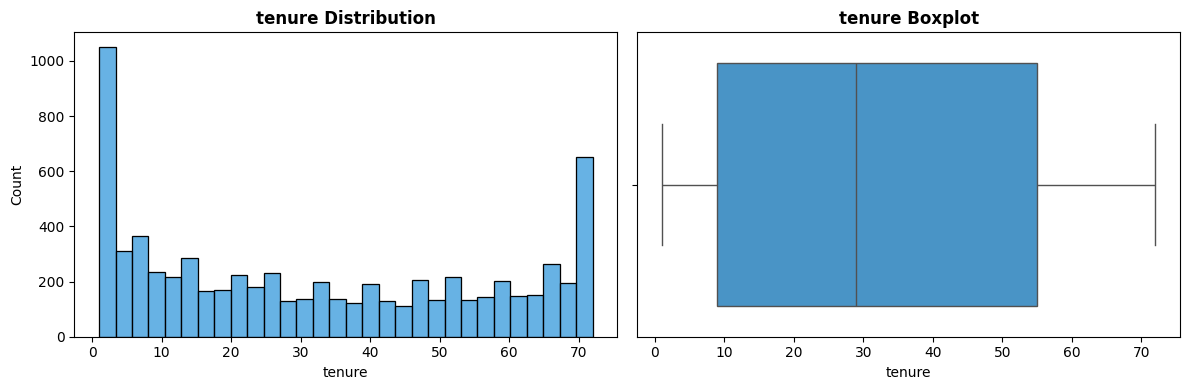

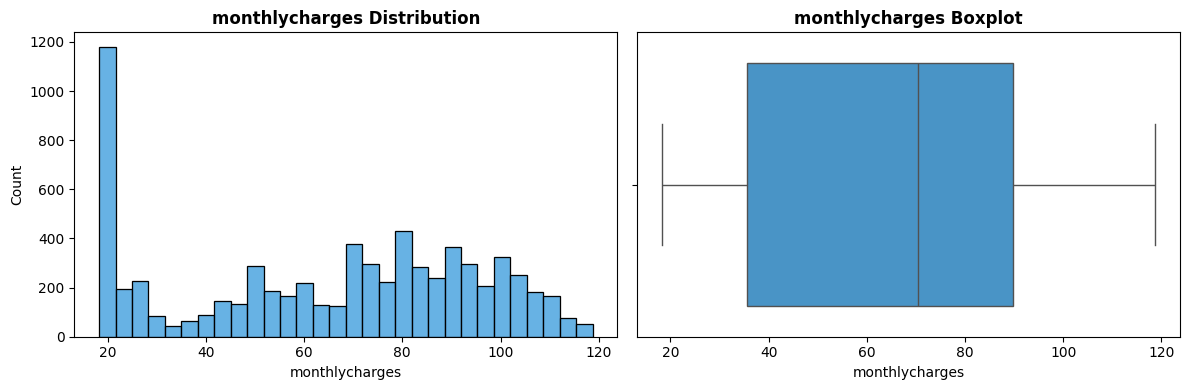

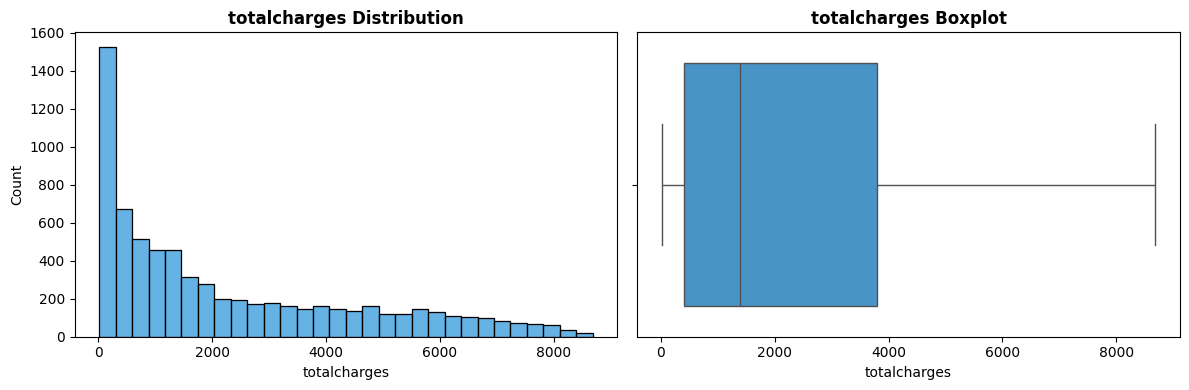

In [166]:
num_cols = ['tenure', 'monthlycharges', 'totalcharges']
cat_cols = ['churn', 'seniorcitizen', 'contract', 'internetservice', 'paymentmethod', 'paperlessbilling']

for col in num_cols:
    univarate_num(col)
    plt.show()

# for col in cat_cols:
#     univarate(col)
#     plt.show()